## Welcome to the code!
Please upload the dataset to Colab first. If you're using local Python, remember to change the file path (you can search for the file using the keyword “recoding”).

# Chi-Square

In [ ]:
# Import necessary libraries
from itertools import combinations
from scipy.stats import chi2_contingency
df2=pd.read_excel("Final_table1_Sample characteristic_no whole (3).xlsx")
# Define function for pairwise Chi-square tests
def automate_pairwise_chi_square(df):
    # Store results
    results = []

    # Get unique variable types
    variables = df["Variables"].unique()

    # Iterate through each variable
    for var in variables:
        # Extract current variable's data
        var_data = df[df["Variables"] == var]

        # Set contingency table
        contingency_table = var_data.set_index("Category")[["Never Had ADHD", "Had ADHD Before", "Currently Have ADHD"]]

        # Get all pairwise comparisons between ADHD groups
        group_pairs = list(combinations(["Never Had ADHD", "Had ADHD Before", "Currently Have ADHD"], 2))

        for group1, group2 in group_pairs:
            # Extract two groups for comparison
            comparison_table = contingency_table[[group1, group2]]

            # Perform Chi-square test
            chi2_stat, p, dof, expected = chi2_contingency(comparison_table)

            # If p <= 0.05, add an asterisk to indicate significance
            if p <= 0.05:
                p_value = f"{p:.6f}*"
            else:
                p_value = f"{p:.6f}"

            # Store results
            results.append({
                "Variable": var,
                "Group 1": group1,
                "Group 2": group2,
                "Chi2 Statistic": f"{chi2_stat:.6f}",
                "p-value": p_value,
                "Degrees of Freedom": dof
            })

    # Convert to DataFrame
    results_df = pd.DataFrame(results)
    return results_df

# Execute automated pairwise Chi-square tests
pairwise_results_df = automate_pairwise_chi_square(df2)

# Save as Excel file
pairwise_results_df.to_excel("pairwise_chi_square_results.xlsx", index=False)
files.download("pairwise_chi_square_results.xlsx")


# LogisticRegression

## Mapping

In [ ]:
#prepare
from google.colab import files
import pandas as pd
import numpy as np
# uploaded = files.upload()
#loading dataset
df=pd.read_csv('Recoding INT_USEDOC.csv')

# Define row variables and categories for ADHD and internet usage
row_vars = {
    "P_AGEC_R": [1, 2, 3, 4],
    "P_HHSIZE_R": ["1", "2", "3", "4", "5", "6+"],
    "P_GENDER": [1, 2],
    "P_EDUCATION_I_R": [1, 2, 3],
    "P_INCOME_I_R": [1, 2, 3, 4, 5],
    "P_RACE_R": [1, 2, 3, 4],
    "P_POVERTY": [1, 2, 3, 4, 5, 6, 7, 8, 9],
    "P_EMPLOY": [1, 2, 3, 4],
    "P_MARITAL": [1, 2, 3, 4],
    "P_REGION": [1, 2, 3, 4],
    "P_HOMEOWN": [1, 2, 3],
    "P_METRO_R": [1, 2],
    "P_INSUR": [1, 0, -1],
    "PAY_BILL12M": [0, 1],
    "PAY_PAYWORRY": [1, 2,3],
    "THC_HOUSCOST": [0, 1],
    "THC_TRANSPOR": [0, 1],
    "ACC_HTHUSUAL": [1, 2,3],
    "ACC_HTHTYPE": [0,1, 2,3,4,5],
    "INT_ACCESS":[0,1],
    "INT_USEDOC":[0,1]
}
category_mappings = {
    "P_AGEC_R": {1: "18-24 years old", 2: "25-44 years old", 3: "45-59 years old", 4: "60-70 years old"},### 1234 or 345 check code book(##6.18 check完了之后age每个category的人数差不多 只是年龄看起来分布不太均匀）
    "P_GENDER": {1: "Male", 2: "Female"},
    "P_EDUCATION_I_R": {1: "High school or less", 2: "Some college", 3: "Bachelor's or higher"},
    "P_RACE_R": {1: "White", 2: "Black", 3: "Other", 4: "Hispanic"},#####dummy
    "P_POVERTY": {1: "<0.5", 2: "0.50-1.00", 3: "1.00-1.50", 4: "1.50-2.00", 5: "2.00-2.50",
                  6: "2.50-3.00", 7: "3.00-3.50", 8: "3.50-4.00", 9: "4.00+"},
    "P_EMPLOY": {1: "Working", 2: "Unable to work", 3: "Retired", 4: "Other"},###dummy
    "P_MARITAL": {1: "Married", 2: "Divorced/Separated", 3: "Widowed", 4: "Never married"},###dummy
    "P_REGION": {1: "Northeast", 2: "Midwest", 3: "South", 4: "West"},##dummy
    "P_HOMEOWN": {1: "Owned", 2: "Rented", 3: "No rent"},##dummyc
    "P_METRO_R": {1: "Metro", 2: "Non-metro"},
    "P_INSUR": {1: "Insured", 0: "Uninsured", -1: "Didn't response"},##dummy
    "P_INCOME_I_R": {1: "$0-19,999", 2: "$20,000-39,999", 3: "$40,000-84,999", 4: "$85,000-149,999", 5: "$150,000+"},
    "PAY_BILL12M": {0: "No", 1: "Yes"},
    "PAY_PAYWORRY": {1: "Very worried ", 2: "Somewhat worried ", 3: "Not at all worried "},
    "THC_HOUSCOST": {0: "No", 1: "Yes"},
    "THC_TRANSPOR": {0: "No lack of reliable transportation", 1: "Lack of reliable transportation"},
    "ACC_HTHUSUAL": {1: "has a single usual place to go for care", 2: "No Place", 3: "more than one place"},#dummy
    "ACC_HTHTYPE": {0: "do not go to one place most often ", 1: "A doctor's office or health center ", 2: "Urgent care place", 3: "Hospital emergency room ", 4: "A VA medical center or VA outpatient clinic ", 5: "Some other place"},#dummy
    "INT_ACCESS":{0:"No",1:"Yes"},
    "INT_USEDOC":{0:"No",1:"Yes"}
}

## Missing values before creating dummies

In [ ]:
df = df.dropna(subset=["P_RACE_R", "P_INSUR",'P_INCOME_I_R'])
df["P_AGEC_R"] = pd.cut(df["P_AGEC_R"],
                        bins=[17, 24, 44, 59, 70],
                        labels=[1, 2, 3, 4],
                        include_lowest=True)


df["P_INCOME_I_R"] = pd.cut(df["P_INCOME_I_R"],
                          bins=[0, 8, 12, 16],  # 设置分界点
                          labels=[1, 2, 3],     # 设定分类标签
                          include_lowest=True)  # 确保包含最低值



df = df[~df["ADHD_TELE"].isin([-6, -8])]
df = df[df['ACC_HTHUSUAL'] != -6]


x_columns = [
     "P_AGEC_R",'P_HHSIZE_R','P_GENDER','P_EDUCATION_I_R','P_RACE_R',"P_INCOME_I_R","P_METRO_R","P_REGION",
     "P_POVERTY", "P_EMPLOY", "P_MARITAL","P_HOMEOWN",'P_INSUR','PAY_BILL12M',"PAY_PAYWORRY", "THC_HOUSCOST", "THC_TRANSPOR", "ACC_HTHTYPE",'ACC_HTHUSUAL'
     ]

df[x_columns] = df[x_columns].astype('category')
df['ADHD_TELE']=df['ADHD_TELE'].astype('category')
X = df[x_columns]
y = df["ADHD_TELE"]
y=df['ADHD_TELE']
df = df[~df["ADHD_TELE"].isin([-6, -8])]

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import statsmodels.api as sm

# 拆分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 初始化并训练模型
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

# 查看预测表现
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
X_train_sm = sm.add_constant(X_train).astype(float)
y_train_sm = y_train.astype(float)

logit_model = sm.Logit(y_train_sm, X_train_sm)
result = logit_model.fit()
print(result.summary())

              precision    recall  f1-score   support

           0       0.59      0.77      0.67        30
           1       0.65      0.45      0.53        29

    accuracy                           0.61        59
   macro avg       0.62      0.61      0.60        59
weighted avg       0.62      0.61      0.60        59

Optimization terminated successfully.
         Current function value: 0.596414
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:              ADHD_TELE   No. Observations:                  235
Model:                          Logit   Df Residuals:                      215
Method:                           MLE   Df Model:                           19
Date:                Sat, 12 Jul 2025   Pseudo R-squ.:                  0.1286
Time:                        14:56:23   Log-Likelihood:                -140.16
converged:                       True   LL-Null:                       -160.84
Covariance Type:  

#Table 1 calculation

In [ ]:
df['INT_USEDOC'].value_counts()
# df['population']=df['population'].astype('category')
# df['population'].describe()
adhd_categories = {
    "Never had ADHD": (df["ADHD_EVER"] == 0),
    "Had ADHD Before": (df["ADHD_EVER"] == 1) & (df["ADHD_NOW"] == 0),
    "Currently have ADHD": (df["ADHD_NOW"] == 1)
}
# four populations
# internet_usage_categories = {
    #"Access to Internet": (df["INT_ACCESS"] == 1),
    #"No Access to Internet": (df["INT_ACCESS"] == 0),
    #"Uses Internet to communicate with doctor": (df["INT_USEDOC"] == 1),
    #"Doesn't use Internet to communicate with doctor": (df["INT_USEDOC"] == 0)
#}

never_had_adhd_total = df[df["ADHD_EVER"] == 0].shape[0]
had_adhd_before_total = df[(df["ADHD_EVER"] == 1) & (df["ADHD_NOW"] == 0)].shape[0]
currently_have_adhd_total = df[df["ADHD_NOW"] == 1].shape[0]

print(f"Never Had ADHD Total: {never_had_adhd_total}")
print(f"Had ADHD Before Total: {had_adhd_before_total}")
print(f"Currently Have ADHD Total: {currently_have_adhd_total}")

Never Had ADHD Total: 0
Had ADHD Before Total: 0
Currently Have ADHD Total: 294


In [ ]:
adhd_categories = {
    "Never had ADHD": (df["ADHD_EVER"] == 0),
    "Had ADHD Before": (df["ADHD_EVER"] == 1) & (df["ADHD_NOW"] == 0),
    "Currently have ADHD": (df["ADHD_NOW"] == 1)
}
# four populations
# internet_usage_categories = {
    #"Access to Internet": (df["INT_ACCESS"] == 1),
    #"No Access to Internet": (df["INT_ACCESS"] == 0),
    #"Uses Internet to communicate with doctor": (df["INT_USEDOC"] == 1),
    #"Doesn't use Internet to communicate with doctor": (df["INT_USEDOC"] == 0)
#}

never_had_adhd_total = df[df["ADHD_EVER"] == 0].shape[0]
had_adhd_before_total = df[(df["ADHD_EVER"] == 1) & (df["ADHD_NOW"] == 0)].shape[0]
currently_have_adhd_total = df[df["ADHD_NOW"] == 1].shape[0]

print(f"Never Had ADHD Total: {never_had_adhd_total}")
print(f"Had ADHD Before Total: {had_adhd_before_total}")
print(f"Currently Have ADHD Total: {currently_have_adhd_total}")


output_columns = ["Variables", "Category", "Never Had ADHD", "Had ADHD Before", "Currently Have ADHD", "Whole Population"]


output_table = pd.DataFrame(columns=output_columns)


for row_var, categories in row_vars.items():

    output_table = pd.concat(
        [output_table, pd.DataFrame({"Variables": [row_var], "Category": [""]})],
        ignore_index=True,
    )

    for category in categories:

        category_label = category_mappings.get(row_var, {}).get(category, category)

        row_data = {"Variables": "", "Category": category_label}


        if row_var == "P_AGEC_R":

            age_bins = [0, 24, 44, 59, 70]
            age_labels = ["18-24 years old", "25-44 years old", "45-59 years old", "60-70 years old"]
            whole_population_count = pd.cut(df[row_var], bins=age_bins, labels=age_labels).value_counts().get(category_label, 0)
        elif row_var == "P_HHSIZE_R":

            whole_population_count = df[row_var].value_counts().get(int(category) if category != "6+" else 6, 0)
        else:

            whole_population_count = df[row_var].value_counts().get(category, 0)

        row_data["Whole Population"] = whole_population_count


        never_adhd_filter = df["ADHD_EVER"] == 0
        if row_var == "P_AGEC_R":
            count = pd.cut(df[never_adhd_filter][row_var], bins=age_bins, labels=age_labels).value_counts().get(category_label, 0)
        elif row_var == "P_HHSIZE_R":
            count = df[never_adhd_filter][row_var].value_counts().get(int(category) if category != "6+" else 6, 0)
        else:
            count = df[never_adhd_filter][row_var].value_counts().get(category, 0)

        row_data["Never Had ADHD"] = count

        had_adhd_before_filter = (df["ADHD_EVER"] == 1) & (df["ADHD_NOW"] == 0)
        currently_have_adhd_filter = df["ADHD_NOW"] == 1

        for adhd_status, adhd_filter in [
            ("Had ADHD Before", had_adhd_before_filter),
            ("Currently Have ADHD", currently_have_adhd_filter),
        ]:
            if row_var == "P_AGEC_R":
                count = pd.cut(df[adhd_filter][row_var], bins=age_bins, labels=age_labels).value_counts().get(category_label, 0)
            elif row_var == "P_HHSIZE_R":
                count = df[adhd_filter][row_var].value_counts().get(int(category) if category != "6+" else 6, 0)
            else:
                count = df[adhd_filter][row_var].value_counts().get(category, 0)

            row_data[adhd_status] = count


        output_table = pd.concat(
            [output_table, pd.DataFrame([row_data])], ignore_index=True
        )


    output_table = pd.concat(
        [output_table, pd.DataFrame([{"Variables": "", "Category": ""}])],
        ignore_index=True,
    )


output_table.to_excel("table1_update.xlsx", index=False)

Never Had ADHD Total: 0
Had ADHD Before Total: 0
Currently Have ADHD Total: 294


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# PCA+SVM

In [ ]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df=pd.read_csv('Recoding INT_USEDOC.csv')
df = df[((df["ADHD_NOW"] == 1) | ((df["ADHD_NOW"] == 0)&(df["ADHD_EVER"] == 1)))]#this entry

df['population'] = df['ADHD_NOW'].apply(lambda x: 1 if x == 1 else 0)
print(df['population'].value_counts())

x_columns = [
    "P_AGEC_R", 'P_HHSIZE_R','P_GENDER','P_EDUCATION_I_R','P_RACE_R',"P_INCOME_I_R","P_METRO_R","P_REGION",
    "P_POVERTY", "P_EMPLOY", "P_MARITAL", "P_HOMEOWN",'population','P_INSUR','PAY_BILL12M',"PAY_PAYWORRY", "THC_HOUSCOST", "THC_TRANSPOR", "ACC_HTHTYPE",'ACC_HTHUSUAL'
    ,"INT_USEDOC"]

df = df.dropna(subset=["P_RACE_R", "P_INSUR",'P_INCOME_I_R'])
target_column = 'ADHD_TELE'
X = df[x_columns]
y = df[target_column]

df = df[(df[target_column] != -8) & (df[target_column] != -6)]

population
1    444
0    124
Name: count, dtype: int64


Fitting 10 folds for each of 160 candidates, totalling 1600 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=10.
  warnings.warn(


Best Parameters: {'svm__C': 0.1, 'svm__class_weight': None, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
Best Cross-Validation Score: 0.7550537634408603

Classification Report on Test Set:
              precision    recall  f1-score   support

          -8       1.00      1.00      1.00        14
           0       0.67      0.81      0.73        32
           1       0.75      0.58      0.65        31

    accuracy                           0.75        77
   macro avg       0.81      0.80      0.80        77
weighted avg       0.76      0.75      0.75        77


Explained Variance Ratio of PCA Components: [0.15115546 0.08845065 0.0761053  0.06593772 0.06166171 0.05700012
 0.05439961 0.0536938  0.04867416 0.04491407 0.04335112 0.03656091
 0.0355968  0.03403176 0.03104788 0.02960442 0.02715883 0.02316293
 0.01919417 0.0167746  0.00152399]
Explained Variance Ratio for each component:
PC1: 0.1512 (15.12%)
PC2: 0.0885 (8.85%)
PC3: 0.0761 (7.61%)
PC4: 0.0659 (6.59%)
PC5: 0.0617 (6.17%)


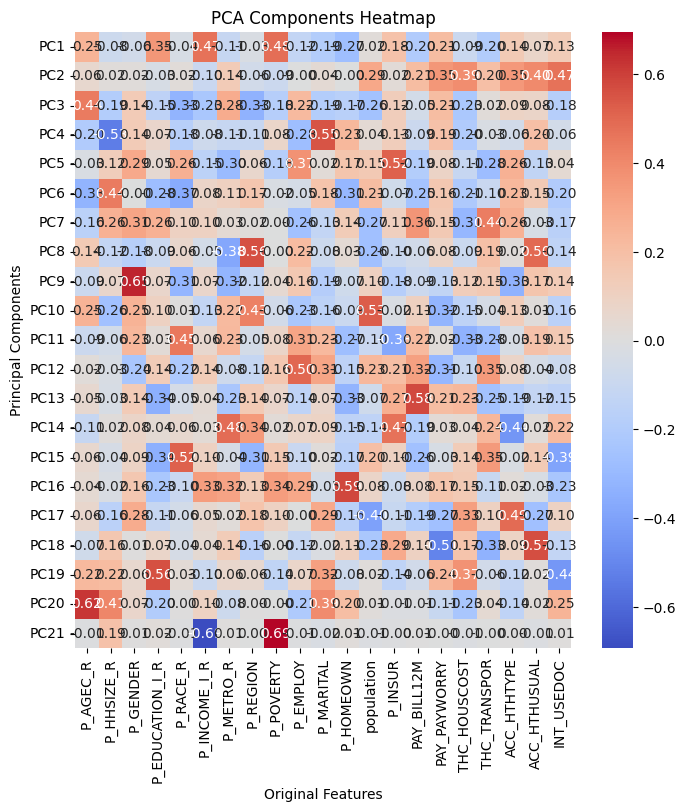

In [ ]:
# 3. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Define PCA and SVM pipeline
# StandardScaler: standardize features by removing the mean and scaling to unit variance
# PCA: reduce the dimensionality of the dataset
# SVC: support vector classifier
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Standardize the data
    ('pca', PCA()),  # PCA for dimensionality reduction
    ('svm', SVC(probability=True))  # SVM classifier
])

# 5. Define hyperparameter grid for GridSearchCV
# Specify the number of components for PCA and SVM hyperparameters
param_grid = {
    'svm__kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'svm__class_weight': [None, 'balanced']
}

# 6. Perform hyperparameter tuning using GridSearchCV
grid_search = GridSearchCV(pipeline, param_grid, cv=10, scoring='accuracy', verbose=1)
grid_search.fit(X_train, y_train)

# 7. Output the best hyperparameters and accuracy
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

# 8. Evaluate the best model on the test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("\nClassification Report on Test Set:")
print(classification_report(y_test, y_pred))

# 9. Analyze PCA explained variance
# To understand how much variance each component explains
pca = best_model.named_steps['pca']
explained_variance_ratio = pca.explained_variance_ratio_
print("\nExplained Variance Ratio of PCA Components:", explained_variance_ratio)
import numpy as np
explained_variance_ratio = pca.explained_variance_ratio_
print("Explained Variance Ratio for each component:")
for i, ratio in enumerate(explained_variance_ratio):
    print(f"PC{i+1}: {ratio:.4f} ({ratio*100:.2f}%)")
cumulative_variance = np.cumsum(explained_variance_ratio)
print("\nCumulative Explained Variance:")
for i, ratio in enumerate(cumulative_variance):
    print(f"PC{i+1}: {ratio:.4f} ({ratio*100:.2f}%)")

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

components_df = pd.DataFrame(pca.components_, columns=X.columns, index=[f"PC{i+1}" for i in range(pca.n_components_)])

plt.figure(figsize=(8, 8))
sns.heatmap(components_df, cmap='coolwarm', annot=True, fmt=".2f")
plt.title("PCA Components Heatmap")
plt.xlabel("Original Features")
plt.ylabel("Principal Components")
plt.show()

## PCA SVM's result

In [ ]:
import pandas as pd


variable_importance = components_df.abs().mean(axis=0)


variable_importance_pct = (variable_importance / variable_importance.sum()) * 100


variable_importance_df = pd.DataFrame({
    "Mean Absolute Contribution": variable_importance,
    "Contribution (%)": variable_importance_pct
}).sort_values(by="Contribution (%)", ascending=False)

# 打印结果（保留两位小数）
print(variable_importance_df.round(2))


                 Mean Absolute Contribution  Contribution (%)
THC_HOUSCOST                           0.19              5.45
INT_USEDOC                             0.18              5.21
PAY_PAYWORRY                           0.18              5.13
THC_TRANSPOR                           0.18              5.09
P_EMPLOY                               0.18              5.04
P_HOMEOWN                              0.18              5.02
P_METRO_R                              0.18              5.01
PAY_BILL12M                            0.17              4.94
population                             0.17              4.91
P_MARITAL                              0.17              4.79
P_EDUCATION_I_R                        0.17              4.77
ACC_HTHTYPE                            0.17              4.75
P_INSUR                                0.17              4.75
P_HHSIZE_R                             0.16              4.64
P_GENDER                               0.16              4.60
P_REGION

# # Few Shot Learning

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report
from torch.utils.data import Dataset, DataLoader


df=pd.read_csv('Recoding INT_USEDOC.csv')
df = df[((df["ADHD_NOW"] == 1) | ((df["ADHD_NOW"] == 0)&(df["ADHD_EVER"] == 1)))]#this entry

df['population'] = df['ADHD_NOW'].apply(lambda x: 1 if x == 1 else 0)
print(df['population'].value_counts())

df = df.dropna(subset=["P_RACE_R", "P_INSUR",'P_INCOME_I_R'])
target_column = 'ADHD_TELE'
df = df[(df[target_column] != -8) & (df[target_column] != -6)]
target_column = 'ADHD_TELE'
X = df[x_columns]
y = df[target_column]

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


imputer = SimpleImputer(strategy="most_frequent")
x_train = pd.DataFrame(imputer.fit_transform(x_train), columns=x_train.columns)
x_test = pd.DataFrame(imputer.transform(x_test), columns=x_test.columns)


class ADHDDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x.values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

train_dataset = ADHDDataset(x_train, y_train)
test_dataset = ADHDDataset(x_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)


class PrototypicalNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super(PrototypicalNetwork, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )

    def forward(self, x):
        return self.encoder(x)


def compute_prototypes(embeddings, labels):
    prototypes = []
    for label in torch.unique(labels):
        prototypes.append(embeddings[labels == label].mean(dim=0))
    return torch.stack(prototypes)


def classify(embeddings, prototypes):

    distances = -torch.cdist(embeddings, prototypes)##recheck
    return distances


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = x_train.shape[1]
model = PrototypicalNetwork(input_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

epochs = 100
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        embeddings = model(x_batch)
        prototypes = compute_prototypes(embeddings, y_batch)
        logits = classify(embeddings, prototypes)

        loss = criterion(logits, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()


model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        embeddings = model(x_batch)
        prototypes = compute_prototypes(embeddings, y_batch)
        logits = classify(embeddings, prototypes)

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())


accuracy = accuracy_score(all_labels, all_preds)
print("Prototypical Network Accuracy of the test dataset:", accuracy)
print(classification_report(all_labels, all_preds))

population
1    444
0    124
Name: count, dtype: int64
Prototypical Network Accuracy of the test dataset: 0.8305084745762712
              precision    recall  f1-score   support

           0       0.85      0.85      0.85        33
           1       0.81      0.81      0.81        26

    accuracy                           0.83        59
   macro avg       0.83      0.83      0.83        59
weighted avg       0.83      0.83      0.83        59



## new evaluation

In [ ]:
##############################################################
import torch.nn.functional as F

def evaluate_few_shot(model, x_data, y_data, ablate_feature=None, return_confidence=False):
    x = x_data.copy()
    if ablate_feature:
        x[ablate_feature] = 0

    x_tensor = torch.tensor(x.values, dtype=torch.float32).to(device)
    y_tensor = torch.tensor(y_data.values, dtype=torch.long).to(device)

    with torch.no_grad():
        embeddings = model(x_tensor)
        prototypes = compute_prototypes(embeddings, y_tensor)
        logits = classify(embeddings, prototypes)
        probs = F.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        acc = (preds == y_tensor).float().mean().item()
        confidence = probs.max(dim=1).values.mean().item()

    if return_confidence:
        return confidence
    else:
        return acc
def average_ablation(model, x_data, y_data, feature, num_trials=10, sample_size=32, use_confidence=True, return_all=False):
    drops = []
    for _ in range(num_trials):
        idx = np.random.choice(len(x_data), size=sample_size, replace=False)
        x_sample = x_data.iloc[idx].copy()
        y_sample = y_data.iloc[idx].copy()

        metric_fn = lambda *args, **kwargs: evaluate_few_shot(*args, **kwargs, return_confidence=use_confidence)

        full = metric_fn(model, x_sample, y_sample)
        ablate = metric_fn(model, x_sample, y_sample, ablate_feature=feature)
        drops.append(full - ablate)

    if return_all:
        return np.mean(drops), np.std(drops), drops
    return np.mean(drops)
results = {}
for feat in x_columns:
    mean, std, _ = average_ablation(model, x_test, y_test, feat, num_trials=10, use_confidence=True, return_all=True)
    results[feat] = (mean, std)

print(f"{'Feature':<20}{'Avg ConfDrop':>15}")
for feat, (mean, std) in sorted(results.items(), key=lambda x: x[1][0], reverse=True):
    print(f"{feat:<20}{mean:15.4f}")

Feature                Avg ConfDrop
INT_USEDOC                   0.0938
P_INCOME_I_R                 0.0723
P_AGEC_R                     0.0719
P_RACE_R                     0.0473
P_INSUR                      0.0256
P_METRO_R                    0.0163
P_GENDER                     0.0152
ACC_HTHUSUAL                 0.0138
P_MARITAL                    0.0089
PAY_BILL12M                  0.0063
population                   0.0044
THC_TRANSPOR                 0.0004
P_HOMEOWN                   -0.0031
THC_HOUSCOST                -0.0033
P_EDUCATION_I_R             -0.0048
ACC_HTHTYPE                 -0.0105
P_EMPLOY                    -0.0138
PAY_PAYWORRY                -0.0146
P_REGION                    -0.0170
P_HHSIZE_R                  -0.0209
P_POVERTY                   -0.0305


## FSL's importance(original)

In [ ]:
input_weights = model.encoder[0].weight.data.cpu().numpy()

feature_importance = np.mean(np.abs(input_weights), axis=0) #only the input_weights

feature_names = x_train.columns
importance_dict = dict(zip(feature_names, feature_importance))
sorted_importance = sorted(importance_dict.items(), key=lambda x: x[1], reverse=True)

print("Importance of features for Prototypical Network:")
for feature, score in sorted_importance:
    print(f"{feature}: {score:.4f}")

Importance of features for Prototypical Network:
INT_USEDOC: 0.4675
THC_TRANSPOR: 0.2720
P_RACE_R: 0.2247
THC_HOUSCOST: 0.2217
ACC_HTHUSUAL: 0.2154
PAY_BILL12M: 0.2107
P_INSUR: 0.2091
P_REGION: 0.2072
PAY_PAYWORRY: 0.2009
P_METRO_R: 0.2000
P_HOMEOWN: 0.1988
P_MARITAL: 0.1944
P_HHSIZE_R: 0.1899
P_GENDER: 0.1859
ACC_HTHTYPE: 0.1773
P_EDUCATION_I_R: 0.1767
P_EMPLOY: 0.1686
population: 0.1592
P_POVERTY: 0.1505
P_INCOME_I_R: 0.1359
P_AGEC_R: 0.1118


# # Selection LightGBM

In [ ]:
import xgboost
import sklearn
from imblearn.combine import SMOTEENN
print("XGBoost 版本:", xgboost.__version__)
print("Scikit-learn 版本:", sklearn.__version__)
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score # import cross_val_score
!pip install imbalanced-learn

XGBoost 版本: 2.1.4
Scikit-learn 版本: 1.6.1


In [ ]:
df=pd.read_csv('Recoding INT_USEDOC.csv')
df = df[((df["ADHD_NOW"] == 1) | ((df["ADHD_NOW"] == 0)&(df["ADHD_EVER"] == 1)))]#this entry

df['population'] = df['ADHD_NOW'].apply(lambda x: 1 if x == 1 else 0)
print(df['population'].value_counts())

df = df.dropna(subset=["P_RACE_R", "P_INSUR",'P_INCOME_I_R'])
df = df[(df[target_column] != -8) & (df[target_column] != -6)]
target_column = 'ADHD_TELE'
X = df[x_columns]
y = df[target_column]

# **处理 NaN 值**
imputer = SimpleImputer(strategy="most_frequent")
x_train = pd.DataFrame(imputer.fit_transform(x_train), columns=x_train.columns)

# **使用 SMOTEENN（过采样 + 欠采样）**
smoteenn = SMOTEENN(random_state=42)
x_train_resampled, y_train_resampled = smoteenn.fit_resample(x_train, y_train)

# **改用 LightGBM**
clf = LGBMClassifier(n_estimators=200, max_depth=7, learning_rate=0.05, random_state=42)
clf.fit(x_train_resampled, y_train_resampled)

# 预测
y_pred = clf.predict(x_test)

# **计算测试集性能**
print("LightGBM accuracy on test data:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# **10 折交叉验证**
scores = cross_val_score(clf, x_train_resampled, y_train_resampled, cv=10, scoring='accuracy')
print("10 fold cross-validation score accuracy:", scores.mean())

feature_importance = clf.feature_importances_


population
1    444
0    124
Name: count, dtype: int64
[LightGBM] [Info] Number of positive: 26, number of negative: 28
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000169 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 64
[LightGBM] [Info] Number of data points in the train set: 54, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.481481 -> initscore=-0.074108
[LightGBM] [Info] Start training from score -0.074108
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [W

In [ ]:
feature_importance = clf.feature_importances_

## LightGBM's result

In [ ]:
feature_names = x_train_resampled.columns
for i, importance in enumerate(feature_importance):
    print(f"Feature {feature_names[i]}: Importance = {importance}")

Feature P_AGEC_R: Importance = 39
Feature P_HHSIZE_R: Importance = 0
Feature P_GENDER: Importance = 33
Feature P_EDUCATION_I_R: Importance = 0
Feature P_RACE_R: Importance = 0
Feature P_INCOME_I_R: Importance = 37
Feature P_METRO_R: Importance = 0
Feature P_REGION: Importance = 0
Feature P_POVERTY: Importance = 0
Feature P_EMPLOY: Importance = 0
Feature P_MARITAL: Importance = 17
Feature P_HOMEOWN: Importance = 34
Feature population: Importance = 0
Feature P_INSUR: Importance = 0
Feature PAY_BILL12M: Importance = 0
Feature PAY_PAYWORRY: Importance = 0
Feature THC_HOUSCOST: Importance = 0
Feature THC_TRANSPOR: Importance = 0
Feature ACC_HTHTYPE: Importance = 0
Feature ACC_HTHUSUAL: Importance = 40
Feature INT_USEDOC: Importance = 0
